In [1]:
# !pip3 install gdown
# !pip3 install liac-arff
# !pip3 install catboost

#### Прочитаем данные с шары (было лень разбираться с тем, что файл не влезал на гит)

In [2]:
import gdown
import arff
import pandas as pd
import os
import scipy.stats as sps
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import roc_auc_score, r2_score
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

url = "https://drive.google.com/file/d/12gj4WVrV0vPCM0leqPdyWWfDnuvzNl_X/view?usp=share_link"
output_path = "../data/raw/downloaded_file.arff"

gdown.download(url, output_path, fuzzy=True, quiet=False)

/Users/polushkin-ayu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12gj4WVrV0vPCM0leqPdyWWfDnuvzNl_X
To: /Users/polushkin-ayu/Multiplicative_bias/data/raw/downloaded_file.arff
100%|██████████████████████████████████████| 36.3M/36.3M [00:01<00:00, 24.9MB/s]


'../data/raw/downloaded_file.arff'

In [3]:
os.path.getsize(output_path)/(1024**2)

34.6074743270874

In [4]:
with open(output_path, "r", encoding="utf-8", errors="ignore") as f:
    dataset = arff.load(f)

columns = [attr[0] for attr in dataset["attributes"]]
df = pd.DataFrame(dataset["data"], columns=columns)

os.remove(output_path) #сносим, чтобы пушилось без проблем

In [5]:
target = 'ClaimNb'
features_list = ['Exposure','Area','VehPower','VehAge',
                 'DrivAge','BonusMalus','VehBrand',
                 'VehGas','Density','Region']

Будем учить 2 модели: на ClaimNb = 0 и регрессию при условии ненулевой ClaimNb.
В качестве архитектуры выберем CatBoost как дающий хороший результат без сильной предварительной подготовки фичей

In [6]:
df = df.assign(random = sps.randint.rvs(0,3,size=len(df), random_state=42))
df['group'] = df.random.apply(lambda x: 'test' if x == 0 else 'val' if x == 1 else 'train')

In [7]:
# def concatenate_many_times(df,n_times):
#     if n_times == 2:
#         df = pd.concat([df, df])
#     else:
#         df = pd.concat([df, concatenate_many_times(df, n_times - 1)])
#     return(df)

# df = pd.concat([df, 
#                 concatenate_many_times(df[df.ClaimNb == 2], 10), 
#                 concatenate_many_times(df[df.ClaimNb == 3], 20),
#                 concatenate_many_times(df[df.ClaimNb == 4], 50)]) 

df\
    .groupby('Region')\
    .agg(n_obs = ('IDpol','count'))\
    .sort_values('n_obs', ascending=False)\
    .reset_index()
# Замножим строки с высоким числом аварий для симуляции зависимости в данных

,Region,n_obs
0,R24,160601
1,R82,84752
2,R93,79315
3,R11,69791
4,R53,42122
5,R52,38751
6,R91,35805
7,R72,31329
8,R31,27285
9,R54,19046


In [8]:
df.groupby('group')\
    .agg(mean_target = ('ClaimNb','mean'),
        sample_size = ('IDpol','nunique'))\
    .reset_index()

,group,mean_target,sample_size
0,test,0.052846,226354
1,train,0.053289,226030
2,val,0.053606,225629


In [9]:
df['nonzero_target'] = (df.ClaimNb > 0).astype('int')

In [10]:
df_train = df[df.group == 'train']
df_val = df[df.group == 'val']
df_test = df[df.group == 'test']

In [11]:
# nonzero_model = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=3, logging_level='Silent')
X_train = df_train[features_list]
y_train = df_train['nonzero_target']
iters_grid = np.arange(50,400,50)
n = len(iters_grid)
aucs_train = np.empty(n)
aucs_val = np.empty(n)
X_val = df_val[features_list]
y_val = df_val['nonzero_target']

for i in tqdm(range(n)):
    nonzero_model = CatBoostClassifier(iterations=iters_grid[i], learning_rate=0.05, depth=3, logging_level='Silent')
    nonzero_model.fit(X_train, y_train, cat_features=[1,6,7,9])
    y_pred_train = nonzero_model.predict_proba(X_train)[:,1]
    y_pred_val = nonzero_model.predict_proba(X_val)[:,1]
    aucs_train[i] = roc_auc_score(y_train, y_pred_train)
        # (y_pred_train.mean() - y_train.mean())/y_train.mean()
    #roc_auc_score(y_train, y_pred_train)
    aucs_val[i] = roc_auc_score(y_val, y_pred_val)
        # (y_pred_val.mean() - y_val.mean())/y_val.mean()
    #roc_auc_score(y_val, y_pred_val)

100%|█████████████████████████████████████████████| 7/7 [00:57<00:00,  8.27s/it]


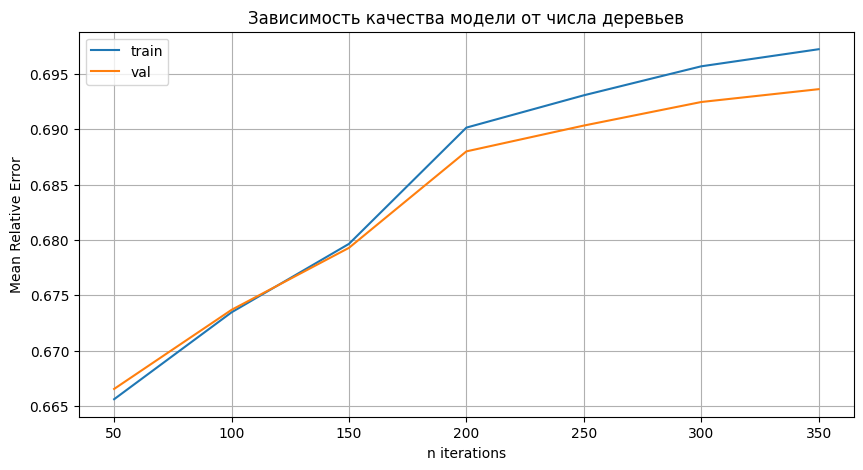

In [12]:
plt.figure(figsize=(10,5))

plt.title('Зависимость качества модели от числа деревьев')

plt.plot(iters_grid, aucs_train, label='train')
plt.plot(iters_grid, aucs_val, label='val')

plt.grid()

plt.xlabel('n iterations')
plt.ylabel('Mean Relative Error')

plt.legend()

plt.show()

In [13]:
# остановились на 150 деревьях
nonzero_model = CatBoostClassifier(iterations=350, learning_rate=0.05, depth=3, logging_level='Silent')
nonzero_model.fit(X_train, y_train, cat_features=[1,6,7,9])

CatBoostClassifier(depth=3, iterations=350, learning_rate=0.05, logging_level='Silent')

In [14]:
X_val = df_val[features_list]
y_val = df_val['nonzero_target']

y_pred_val = nonzero_model.predict_proba(X_val)[:,1]

In [15]:
y_pred_val.mean(), y_val.mean()

(np.float64(0.05021533025690236), np.float64(0.05055201237429586))

In [16]:
print('Relative mean error:' ,round((y_pred_val.mean() - y_val.mean())/y_val.mean() * 100, 2), '%')

Relative mean error: -0.67 %


In [17]:
df_train_act = df_train[df_train.nonzero_target == 1]
df_val_act = df_val[df_val.nonzero_target == 1]

X_train_act, X_val_act = df_train_act[features_list], df_val_act[features_list]
y_train_act, y_val_act = df_train_act[target], df_val_act[target]

In [18]:
iters_grid = np.arange(10,350,10)
n = len(iters_grid)

r2s_train = np.empty(n)
r2s_val = np.empty(n)

for i in tqdm(range(n)):
    cnt_model = CatBoostRegressor(iterations=iters_grid[i], learning_rate=0.01, depth=10, logging_level='Silent')
    cnt_model.fit(X_train_act, y_train_act, cat_features=[1,6,7,9])
    y_pred_train = cnt_model.predict(X_train_act)
    y_pred_val = cnt_model.predict(X_val_act)
    r2s_train[i] = r2_score(y_train_act, y_pred_train)
    # (y_pred_train.mean() - y_train_act.mean())/y_train_act.mean()
    # r2_score(y_train_act, y_pred_train)
    r2s_val[i] = r2_score(y_val_act, y_pred_val)
    # (y_pred_val.mean() - y_val_act.mean())/y_val_act.mean()
    # r2_score(y_val_act, y_pred_val)

100%|███████████████████████████████████████████| 34/34 [00:48<00:00,  1.42s/it]


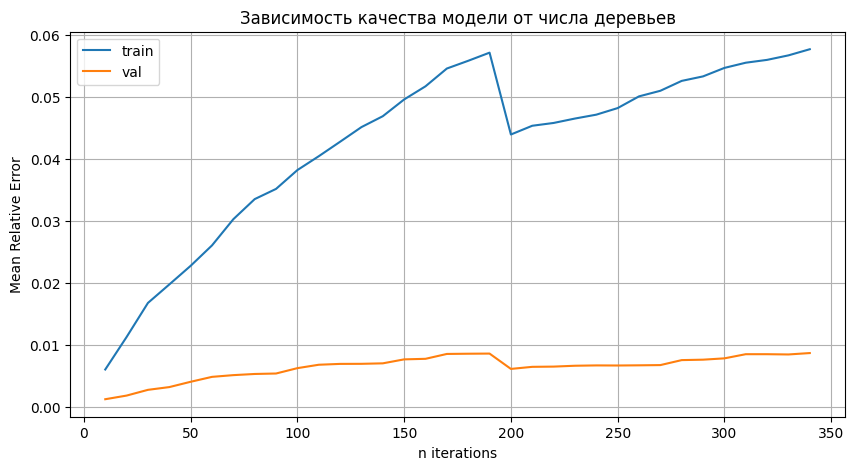

In [19]:
plt.figure(figsize=(10,5))

plt.title('Зависимость качества модели от числа деревьев')

plt.plot(iters_grid, r2s_train, label='train')
plt.plot(iters_grid, r2s_val, label='val')

plt.grid()

plt.xlabel('n iterations')
plt.ylabel('Mean Relative Error')

plt.legend()

plt.show()

In [20]:
# остановились на 250 деревьях глубины 10
cnt_model = CatBoostRegressor(iterations=180, learning_rate=0.01, depth=3, logging_level='Silent')
cnt_model.fit(X_train_act, y_train_act, cat_features=[1,6,7,9])
y_pred_train = cnt_model.predict(X_train_act)
y_pred_val = cnt_model.predict(X_val_act)

In [21]:
print('Relative mean error:' ,round((y_pred_val.mean() - y_val_act.mean())/y_val_act.mean() * 100, 2), '%')

Relative mean error: -0.15 %


In [22]:
X = df[features_list]
act_pred = nonzero_model.predict_proba(X)[:,1]
cnt_act_pred = cnt_model.predict(X)
cnt_pred = act_pred * cnt_act_pred

In [23]:
df['act_pred'] = act_pred
df['cnt_act_pred'] = cnt_act_pred
df['cnt_pred'] = cnt_pred

In [24]:
cnt_pred_val = df[df.group == 'val'].cnt_pred
cnt_real_val = df[df.group == 'val'][target]

print('Relative mean error on validation:' ,round((cnt_pred_val.mean() - cnt_real_val.mean())/cnt_real_val.mean() * 100, 2), '%')

Relative mean error on validation: -0.82 %


In [25]:
cnt_pred_test = df[df.group == 'test'].cnt_pred
cnt_real_test = df[df.group == 'test'][target]

print('Relative mean error on test:' ,round((cnt_pred_test.mean() - cnt_real_test.mean())/cnt_real_test.mean() * 100, 2), '%')

Relative mean error on test: 0.85 %


In [26]:
cnt_pred_train = df[df.group == 'train'].cnt_pred
cnt_real_train = df[df.group == 'train'][target]

print('Relative mean error on train:' ,round((cnt_pred_train.mean() - cnt_real_train.mean())/cnt_real_train.mean() * 100, 2), '%')

Relative mean error on train: -0.11 %


In [27]:
df_test = df[df.group == 'test']

In [33]:
df_test_cut = df_test.copy()

df_test_cut['new_car_flg'] = (df_test_cut.VehAge < 5).astype('int')

In [34]:
cut_full_df_cut = df_test_cut[df_test_cut.nonzero_target == 1]\
    .groupby('new_car_flg')\
    .agg(
        mean_num_pred_act = ('cnt_act_pred','mean'),
        mean_num_act = ('ClaimNb','mean'))\
    .reset_index()
cut_full_df_cut['cnt_rtp_act'] = cut_full_df_cut['mean_num_act']/cut_full_df_cut['mean_num_pred_act']
cut_full_df_cut

,new_car_flg,mean_num_pred_act,mean_num_act,cnt_rtp_act
0,0,1.057330,1.058741,1.001335
1,1,1.060749,1.062731,1.001869


In [35]:
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression()
calibrator.fit(np.array(df_test_cut.new_car_flg).reshape((-1,1)), df_test_cut.nonzero_target)
act_calib = calibrator.predict_proba(np.array(df_test_cut.new_car_flg).reshape((-1,1)))[:,1]
df_test_cut['act_calib'] = act_calib
df_test_cut['cnt_pred_calib'] = df_test_cut['act_calib'] * df_test_cut['cnt_act_pred']


full_df_cut = df_test_cut\
    .groupby('new_car_flg')\
    .agg(n_obs = ('IDpol','count'),
        mean_act_pred = ('act_calib','mean'),
        mean_act = ('nonzero_target','mean'),
        mean_num_pred = ('cnt_pred_calib','mean'),
        mean_num = ('ClaimNb','mean'))\
    .reset_index()
full_df_cut['act_rtp'] = full_df_cut['mean_act']/full_df_cut['mean_act_pred']
full_df_cut['cnt_rtp'] = full_df_cut['mean_num']/full_df_cut['mean_num_pred']

In [36]:
full_df_cut = full_df_cut.merge(cut_full_df_cut, on='new_car_flg')

In [37]:
full_df_cut[['new_car_flg','n_obs','act_rtp','cnt_rtp_act','cnt_rtp']]

,new_car_flg,n_obs,act_rtp,cnt_rtp_act,cnt_rtp
0,0,132164,1.001315,1.001335,1.005529
1,1,94190,1.000079,1.001869,1.003144
